**Pandas — это базовый инструмент для табличных данных в Python.**


Но он не всегда хорошо масштабируется: обычно работает на одном ядре и требует, чтобы данные помещались в оперативную память.

Поэтому появились альтернативы.


**Их главная цель** — ускорить вычисления, использовать несколько ядер процессора, разбивать данные на части и иногда даже распределять обработку между несколькими машинами.

Среди таких библиотек чаще всего упоминают **Polars, Dask, Modin, Vaex и Spark DataFrame.**

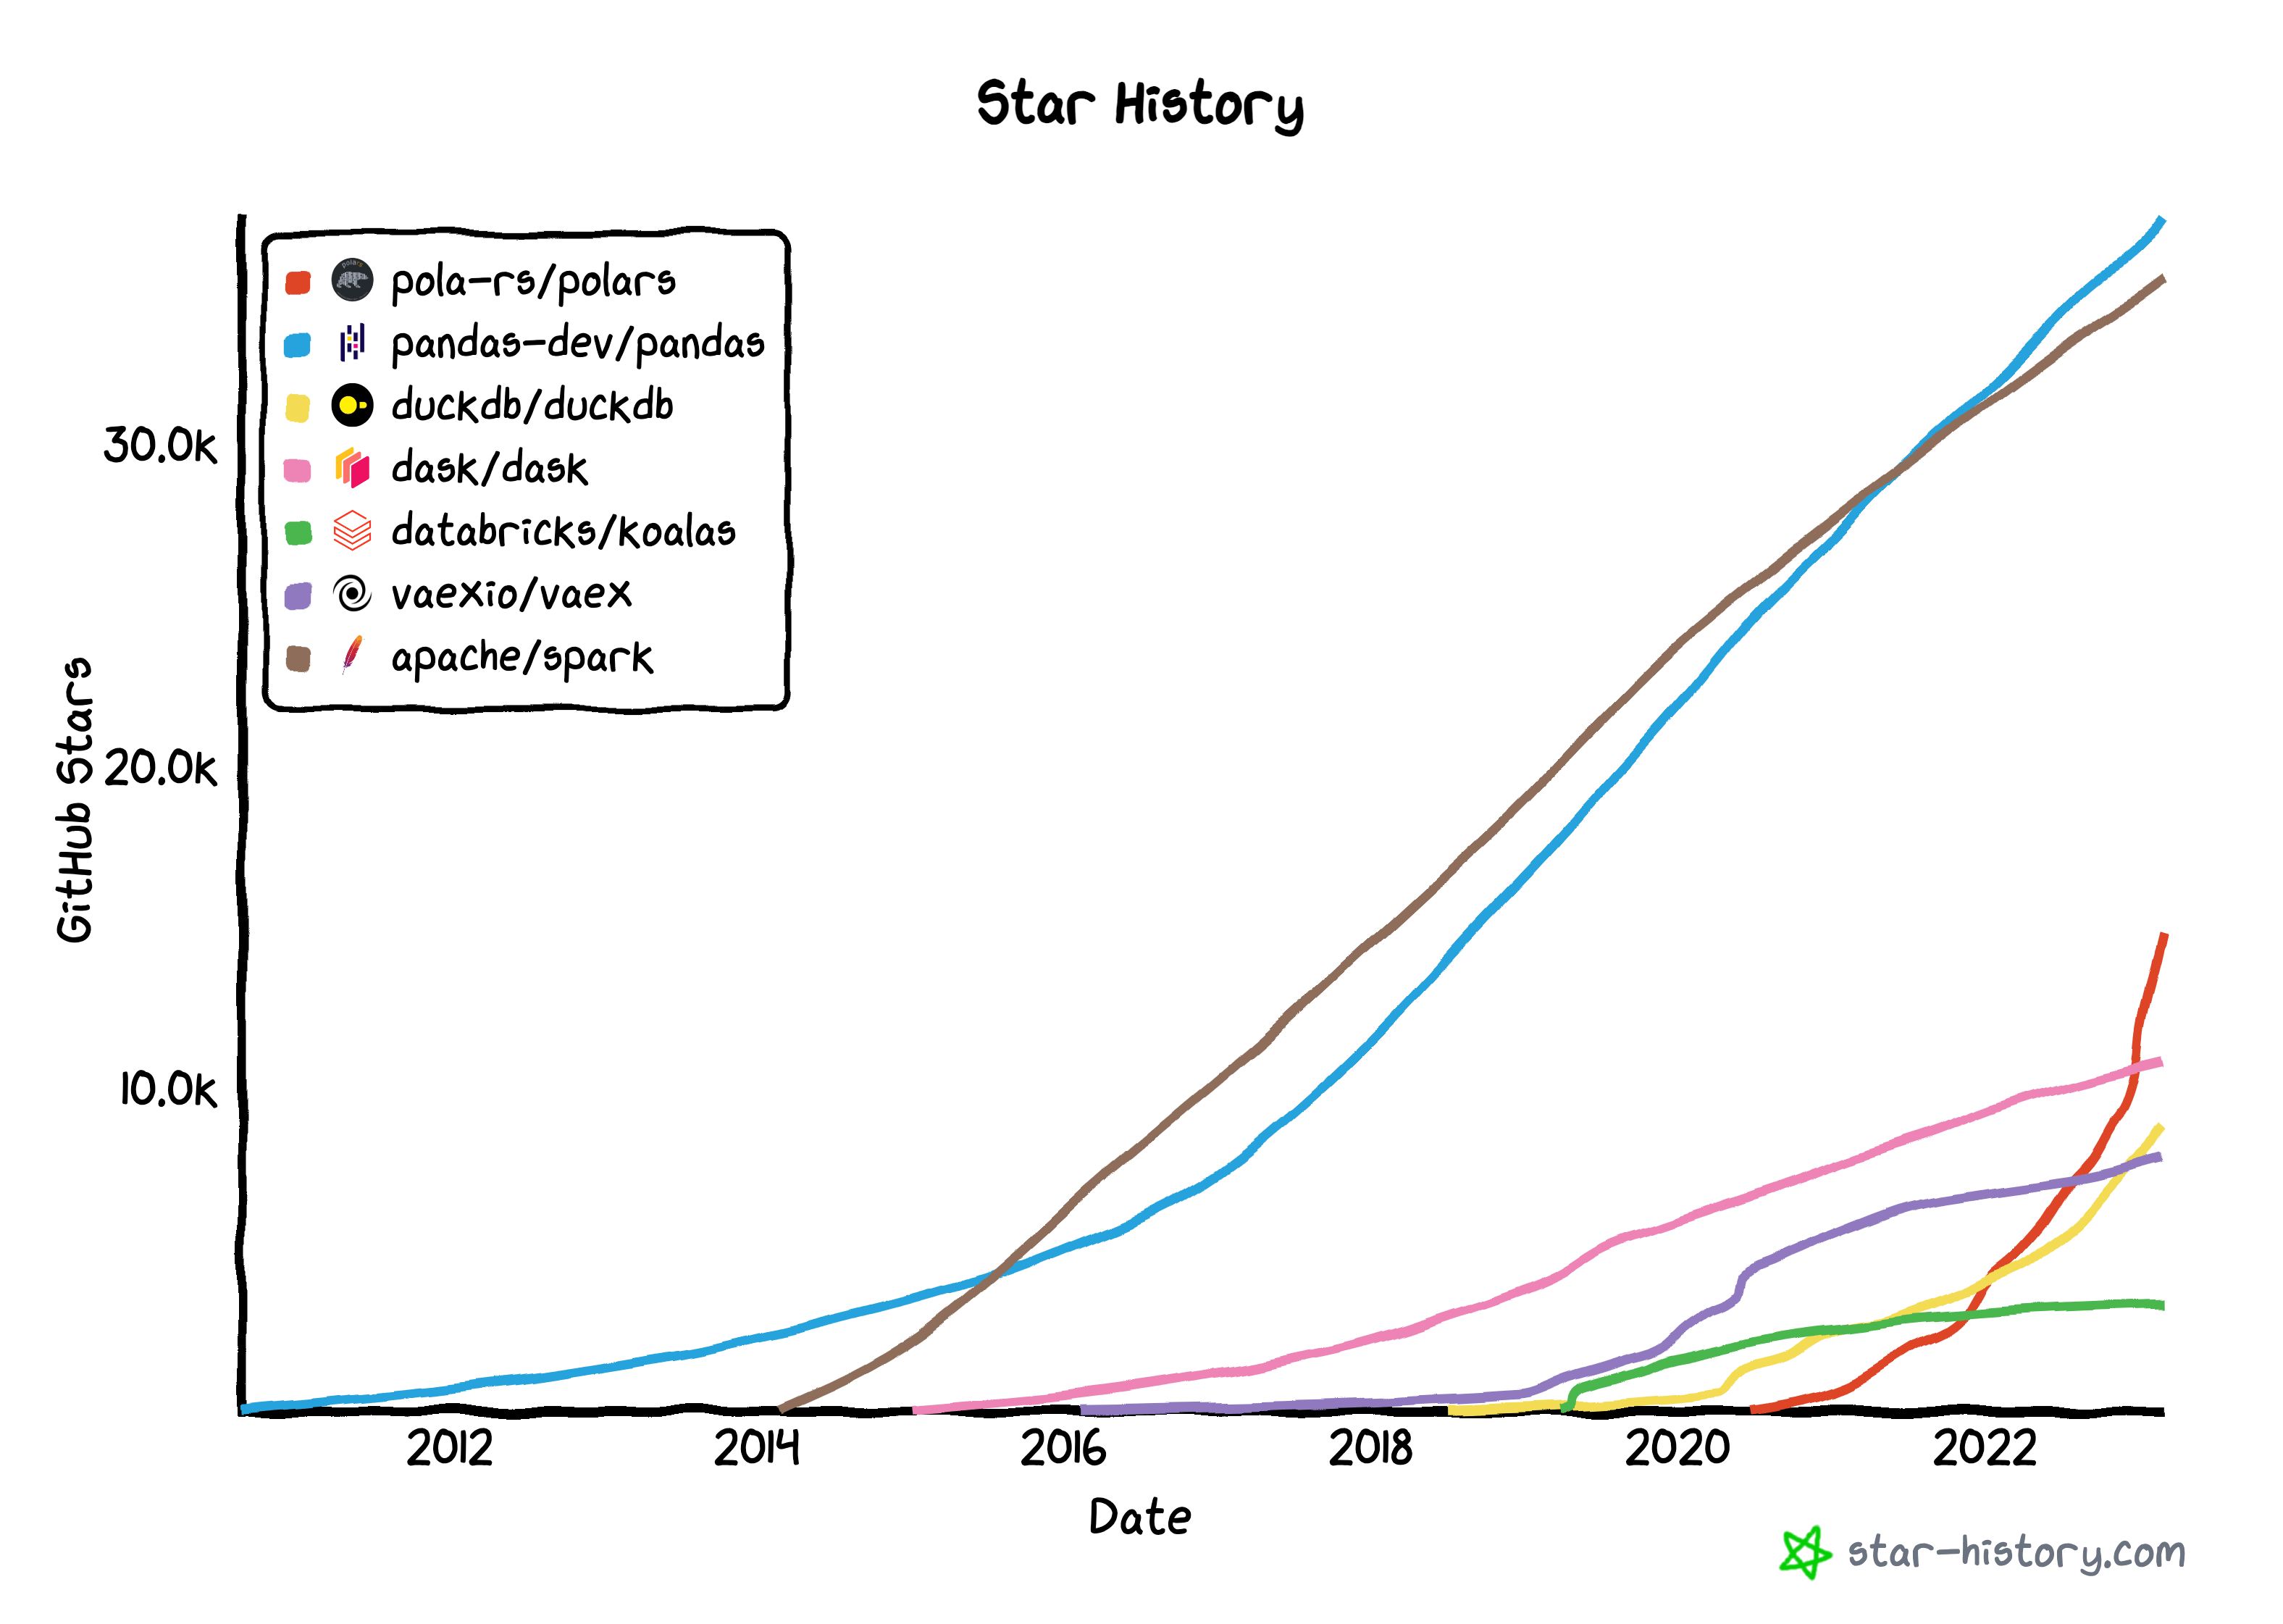

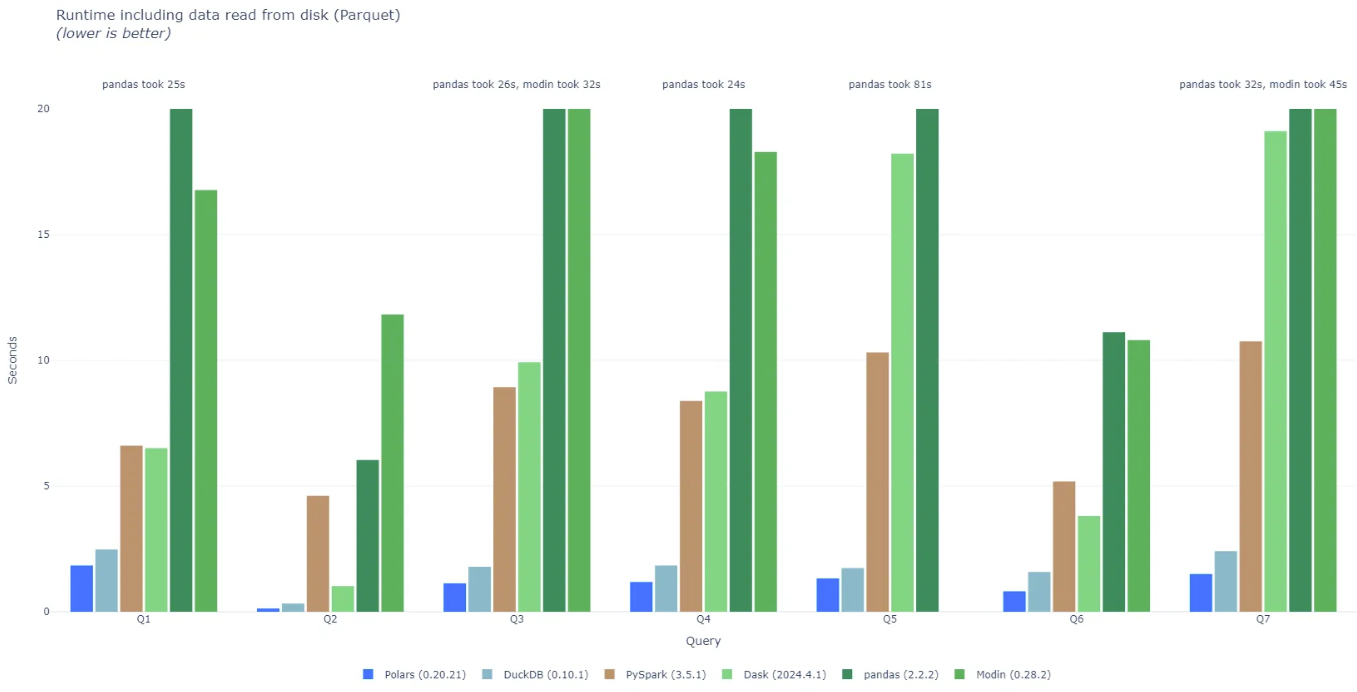

In [1]:
import pandas as pd

## Dask

Dask - пакет для параллельных вычислений на Python, совместимый с NumPy, Pandas, и scikit-learn. В Dask есть структура массивов, которая эквивалентна массивам в NumPy, датафреймы в Dask аналогичны датафреймам в Pandas, а Dask-ML – это аналог scikit-learn.

[Документация](https://docs.dask.org/en/stable/)

In [2]:
!pip install -q "fsspec==2025.3.0" "s3fs==2025.3.0" # для загрузки данных из s3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.3/87.3 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.3/14.3 MB 46.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 kB 5.2 MB/s eta 0:00:00


In [3]:
import dask.dataframe as dd

NYC taxi cab data 2015

Apache Parquet — это бинарный, колоночно-ориентированный формат хранения больших данных

### Dask Arrays

In [4]:
import numpy as np
shape = (1000, 4000)
ones_np = np.ones(shape)
ones_np

array([[1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       ...,
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.]])

In [5]:
print('%.1f MB' % (ones_np.nbytes / (1024 * 1024)))

30.5 MB


In [6]:
import dask.array as da

ones = da.ones(shape)
ones

dask.array<ones_like, shape=(1000, 4000), dtype=float64, chunksize=(1000, 4000), chunktype=numpy.ndarray>

In [7]:
chunk_shape = (1000, 1000)
ones = da.ones(shape, chunks=chunk_shape)
ones

dask.array<ones_like, shape=(1000, 4000), dtype=float64, chunksize=(1000, 1000), chunktype=numpy.ndarray>

In [8]:
ones.compute()

array([[1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       ...,
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.]])

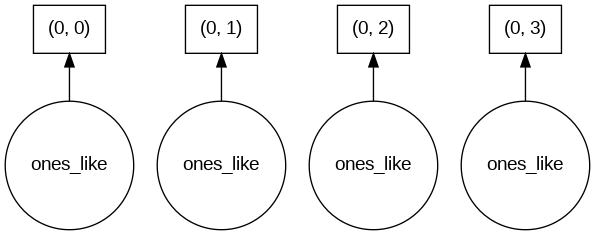

In [9]:
ones.visualize()

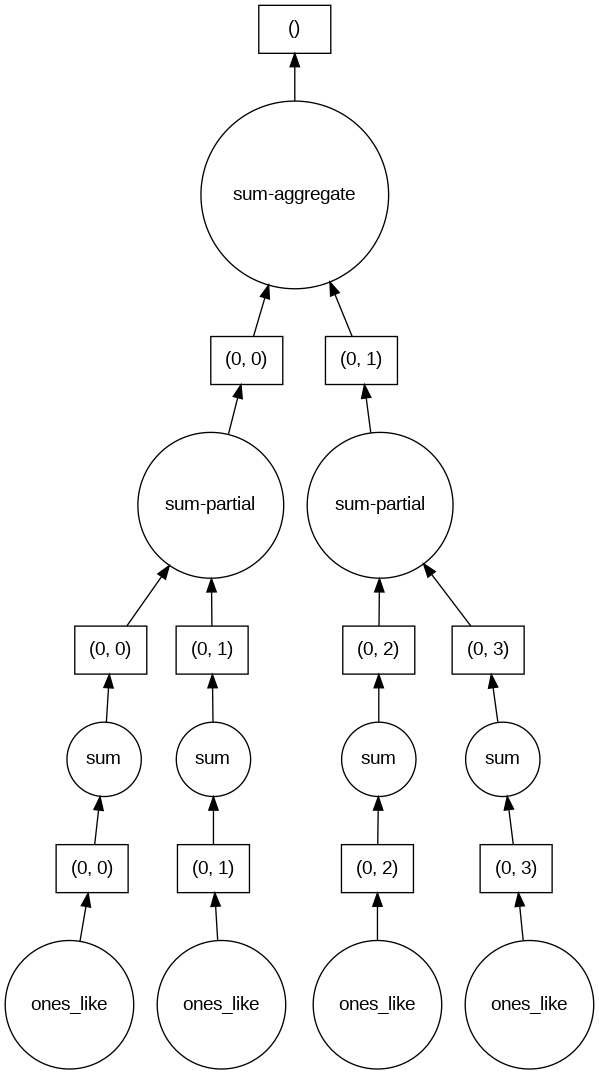

In [10]:
sum_of_ones = ones.sum()
sum_of_ones.visualize()

Возьмем побольше данных

In [11]:
bigshape = (200000, 4000)
big_ones = da.ones(bigshape, chunks=chunk_shape)
big_ones

dask.array<ones_like, shape=(200000, 4000), dtype=float64, chunksize=(1000, 1000), chunktype=numpy.ndarray>

In [12]:
print('%.1f MB' % (big_ones.nbytes / (1024 * 1024)))

6103.5 MB


In [13]:
big_calc = (big_ones * big_ones[::-1, ::-1]).mean()

result = big_calc.compute()
result

np.float64(1.0)

In [14]:
big_ones_reduce = (np.cos(big_ones)**2).mean(axis=1)
big_ones_reduce

dask.array<mean_agg-aggregate, shape=(200000,), dtype=float64, chunksize=(1000,), chunktype=numpy.ndarray>

In [15]:
import gc

del big_ones
del big_ones_reduce

gc.collect()

599

### Dask DataFrame

In [23]:
!pip install -q "dask[dataframe]" "pyarrow


/bin/bash: -c: line 1: unexpected EOF while looking for matching `"'
/bin/bash: -c: line 2: syntax error: unexpected end of file


In [30]:
!wget -O yellow_2015_01.parquet \
  https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2015-01.parquet

--2026-03-17 13:18:38--  https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2015-01.parquet
Resolving d37ci6vzurychx.cloudfront.net (d37ci6vzurychx.cloudfront.net)... 99.84.245.157, 99.84.245.141, 99.84.245.193, ...
Connecting to d37ci6vzurychx.cloudfront.net (d37ci6vzurychx.cloudfront.net)|99.84.245.157|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 175325767 (167M) [application/x-www-form-urlencoded]
Saving to: ‘yellow_2015_01.parquet’

yellow_2015_01.parq 100%[===================>] 167.20M  70.2MB/s    in 2.4s    

2026-03-17 13:18:41 (70.2 MB/s) - ‘yellow_2015_01.parquet’ saved [175325767/175325767]



In [25]:
import dask.dataframe as dd

In [31]:
ddf = dd.read_parquet(
    "yellow_2015_01.parquet",
    columns=["passenger_count", "tip_amount"]
)

print(ddf.head())

   passenger_count  tip_amount
0                1        1.40
1                1        0.00
2                1        2.90
3                1        2.37
4                1        0.00


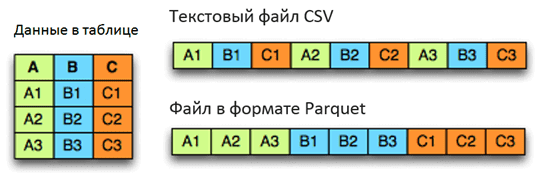

[parquet](https://parquet.apache.org/docs/overview/motivation/)

[Parquet in Action: A Beginners Guide](https://huggingface.co/blog/cfahlgren1/intro-to-parquet-format)

In [32]:
ddf.head()

,passenger_count,tip_amount
0,1,1.40
1,1,0.00
2,1,2.90
3,1,2.37
4,1,0.00


In [33]:
len(ddf)

12741035

In [34]:
type(ddf)

dask.dataframe.dask_expr._collection.DataFrame

Dask DataFrame состоит из множества объектов Pandas DataFrame/Series. Эти объекты pandas могут находиться на одном диске или на разных машинах.

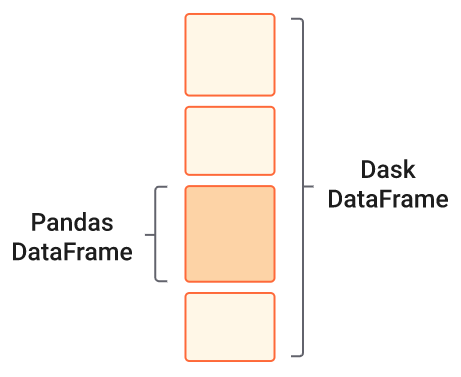

### Ленивые вычисления & граф вычислений

In [35]:
result = ddf.groupby("passenger_count").tip_amount.mean()
result

Dask Series Structure:
npartitions=1
    float64
        ...
Dask Name: getitem, 4 expressions
Expr=((ReadParquetFSSpec(de82c06)[['passenger_count', 'tip_amount']]).mean(observed=False, chunk_kwargs={'numeric_only': False}, aggregate_kwargs={'numeric_only': False}, _slice='tip_amount'))['tip_amount']

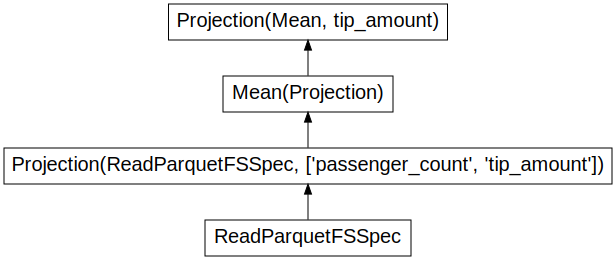

In [36]:
result.visualize()

In [39]:
# result.visualize(filename='dask_graph.pdf')

In [40]:
%%time

result.compute()

CPU times: user 808 ms, sys: 500 ms, total: 1.31 s
Wall time: 1.32 s


,tip_amount
passenger_count,
0,1.441735
1,1.999112
2,1.541431
3,1.440257
4,1.339195
5,1.541967
6,1.505844
7,2.088889
8,1.209000


In [53]:
ddf = dd.read_parquet(
    "yellow_2015_01.parquet",
    columns=["passenger_count", "tip_amount"]
)

print(ddf.head())

   passenger_count  tip_amount
0                1        1.40
1                1        0.00
2                1        2.90
3                1        2.37
4                1        0.00


In [54]:
result = ddf.groupby("passenger_count").tip_amount.mean()
result

Dask Series Structure:
npartitions=1
    float64
        ...
Dask Name: getitem, 4 expressions
Expr=((ReadParquetFSSpec(30d9e0f)[['passenger_count', 'tip_amount']]).mean(observed=False, chunk_kwargs={'numeric_only': False}, aggregate_kwargs={'numeric_only': False}, _slice='tip_amount'))['tip_amount']

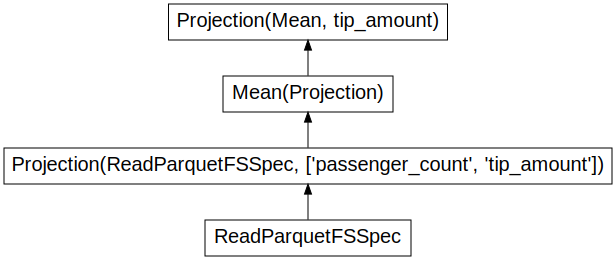

In [52]:
result.visualize()

### Merging Pandas DataFrames

In [41]:
pd_df_1 = pd.DataFrame(
    {
        "Name": ["Azza", "Brandon", "Cedric", "Devonte", "Eli", "Fabio"],
        "Age": [29, 30, 21, 57, 32, 19]
    }
)
ddf_1 = dd.from_pandas(pd_df_1, npartitions=2)

pd_df_2 = pd.DataFrame(
    {
        "Name": ["Azza", "Cedric", "Fabio"],
        "City": ["Beirut", "Dublin", "Rosario"]
    }
)

joined = ddf_1.merge(pd_df_2, how="left", on=["Name"])
joined

,Name,Age,City
npartitions=2,,,
,string,int64,string
,...,...,...
,...,...,...


In [42]:
joined.compute()

,Name,Age,City
0,Azza,29,Beirut
1,Brandon,30,<NA>
2,Cedric,21,Dublin
0,Devonte,57,<NA>
1,Eli,32,<NA>
2,Fabio,19,Rosario


### Dask Delayed

In [43]:
import time

def inc(x):
    time.sleep(0.1)
    return x + 1

def dec(x):
    time.sleep(0.1)
    return x - 1

def add(x, y):
    time.sleep(0.2)
    return x + y

In [44]:
%%timeit

x = inc(1)
y = dec(2)
z = add(x, y)
z

400 ms ± 46.3 µs per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [45]:
import dask

inc = dask.delayed(inc)
dec = dask.delayed(dec)
add = dask.delayed(add)

In [46]:
%%timeit

x = inc(1)
y = dec(2)
z = add(x, y)

153 µs ± 27.3 µs per loop (mean ± std. dev. of 7 runs, 10000 loops each)


In [47]:
x = inc(1)
y = dec(2)
z = add(x, y)

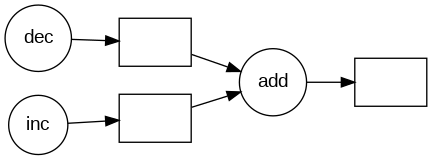

In [48]:
z.visualize(rankdir='LR')

In [49]:
%%timeit

z.compute()

302 ms ± 114 µs per loop (mean ± std. dev. of 7 runs, 1 loop each)
